In [ ]:
# import os
# os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

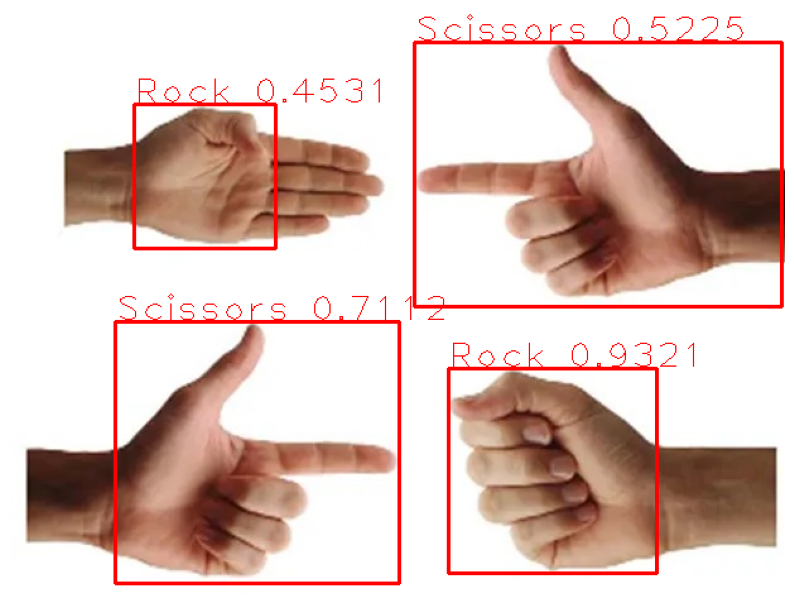

In [1]:
import cv2
import matplotlib.pyplot as plt
from inference_sdk import InferenceHTTPClient

CLIENT = InferenceHTTPClient(
    api_url="https://detect.roboflow.com",
    api_key="RqQEBE0zpu0utPao2x59"
)

filename = './datasets/sample.jpg'
result = CLIENT.infer(filename, model_id="rock-paper-scissors-sxsw/14")
img = cv2.imread(filename)

for pred in result["predictions"]:
    x, y = pred['x'], pred['y']
    width, height = pred['width'], pred['height']
    conf = pred['confidence']
    cls = pred['class']
    x1, y1 = int(x-width/2), int(y-height/2)
    x2, y2 = int(x+width/2), int(y+height/2)
    cv2.rectangle(img, (x1,y1), (x2, y2), (0,0,255), 2)
    cv2.putText(img, f'{cls} {conf:.4f}', (x1,y1), cv2.FONT_HERSHEY_PLAIN, 2, (0,0,255))

plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()

In [ ]:
import torch
print(torch.cuda.is_available())

In [3]:
from roboflow import Roboflow

rf = Roboflow(api_key="RqQEBE0zpu0utPao2x59")

project = rf.workspace().project("rock-paper-scissors-sxsw")

model = project.version(14).model

loading Roboflow workspace...
loading Roboflow project...


In [4]:
filename = './datasets/sample.jpg'

result = model.predict(filename, confidence=40, overlap=30)

result_json= result.json()
print(result_json)

for pred in result_json["predictions"]:
    x = pred['x'] # 사각형의 중심위치 x
    y = pred['y'] # 사각형의 중심위치 y
    width = pred['width']
    height = pred['height']
    conf= pred['confidence']
    cls= pred['class']

    print(x, y, width, height, f'{cls}{conf:.4f}')

{'predictions': [{'x': 412, 'y': 265, 'width': 158, 'height': 117, 'confidence': 0.9322161078453064, 'class': 'Rock', 'class_id': 1, 'detection_id': 'a1223d66-12ae-46a2-b944-f4d249bafbe4', 'image_path': './datasets/sample.jpg', 'prediction_type': 'ObjectDetectionModel'}, {'x': 187, 'y': 255, 'width': 215, 'height': 150, 'confidence': 0.6928563714027405, 'class': 'Scissors', 'class_id': 2, 'detection_id': '25c3811d-12fe-433b-96a9-24401633b23f', 'image_path': './datasets/sample.jpg', 'prediction_type': 'ObjectDetectionModel'}, {'x': 147, 'y': 96, 'width': 108, 'height': 83, 'confidence': 0.48418334126472473, 'class': 'Rock', 'class_id': 1, 'detection_id': '46901823-b3fe-46d9-9fbd-bd0e94736519', 'image_path': './datasets/sample.jpg', 'prediction_type': 'ObjectDetectionModel'}, {'x': 446, 'y': 95, 'width': 278, 'height': 152, 'confidence': 0.4809364676475525, 'class': 'Scissors', 'class_id': 2, 'detection_id': '0b7a022a-371f-4771-9311-8b6a43397530', 'image_path': './datasets/sample.jpg', '

(466, 614, 3)


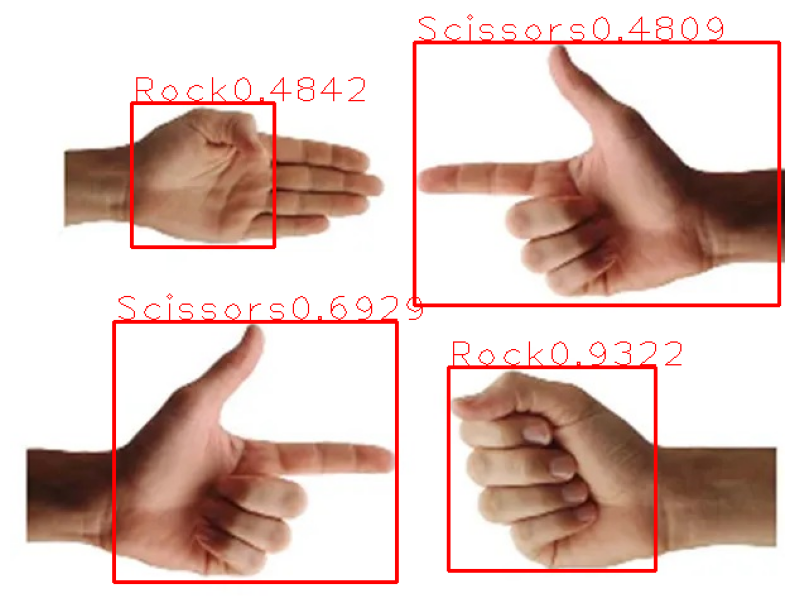

In [11]:
filename = './datasets/sample.jpg'

result = model.predict(filename, confidence=40, overlap=30)
img = cv2.imread(filename)

print(img.shape)

scale_x = img.shape[1] / 640
scale_y = img.shape[0] / 640

for pred in result_json["predictions"]:
    x = pred['x'] / scale_x # 사각형의 중심위치 x
    y = pred['y'] / scale_y # 사각형의 중심위치 y
    
    width = pred['width'] / scale_x
    height = pred['height'] / scale_y
    conf= pred['confidence']
    cls= pred['class']

    x1, y1 = int(x-width/2), int(y-height/2)
    x2, y2 = int(x+width/2), int(y+height/2)
    cv2.rectangle(img, (x1,y1), (x2,y2), (0,0,255), 2)
    cv2.putText(img, f'{cls}{conf:.4f}', (x1,y1), cv2.FONT_HERSHEY_PLAIN, 2, (0,0,255))
    
plt.figure(figsize=(10, 8))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()